In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
file_path = "/content/drive/MyDrive/CSE 438 Lab 1"

# Showing the Figure 1 & 2 Images

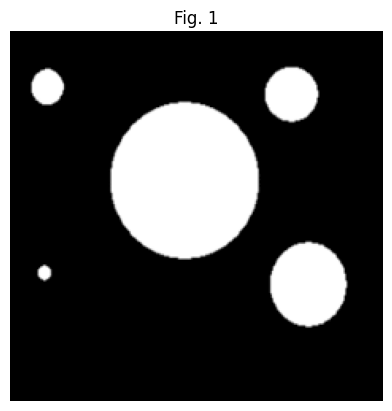

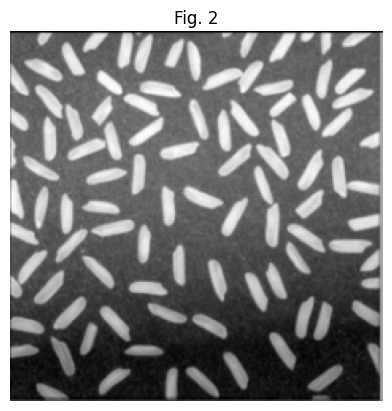

In [13]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy.ndimage import binary_erosion

# Load grayscale images
fig1 = cv2.imread(file_path + '/Figure 1.png', cv2.IMREAD_GRAYSCALE)
fig2 = cv2.imread(file_path + '/Figure 2.png', cv2.IMREAD_GRAYSCALE)

# Resizing fig2 to match fig1's dimensions
fig2 = cv2.resize(fig2, (fig1.shape[1], fig1.shape[0]))

def show_image(img, title="", cmap='gray'):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

show_image(fig1, "Fig. 1")
show_image(fig2, "Fig. 2")

# Q 1. Determine the perimeter of the Figure 1 Image by using 4 connected neighborhoods and 8 connected neighborhoods.

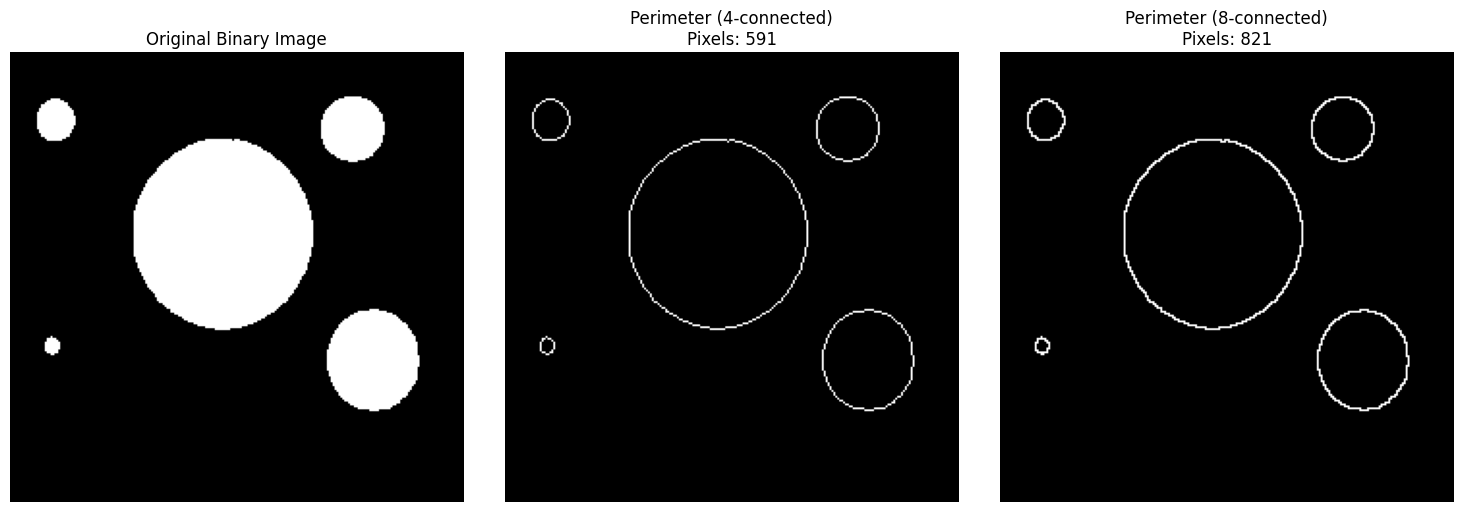

Perimeter (4-connected): 591
Perimeter (8-connected): 821


In [14]:
from scipy.ndimage import binary_erosion

# Convert grayscale image to binary (0 or 1)
_,binary = cv2.threshold(fig1, 127, 1, cv2.THRESH_BINARY)

# Compute perimeter using structuring element
def compute_perimeter(binary_image, connectivity = 4):
    struct = np.array([[0,1,0],
                       [1,1,1],
                       [0,1,0]]) if connectivity == 4 else np.ones((3,3))
    eroded = binary_erosion(binary_image, structure = struct)
    perimeter = binary_image - eroded
    return perimeter, int(np.sum(perimeter))

#Compute both parimeter
perim4_img, perim4_count = compute_perimeter(binary, connectivity=4)
perim8_img, perim8_count = compute_perimeter(binary, connectivity=8)

# Plotting: original + two perimeter results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(binary, cmap='gray')
axes[0].set_title("Original Binary Image")
axes[0].axis("off")
axes[1].imshow(perim4_img, cmap='gray')
axes[1].set_title(f"Perimeter (4-connected)\nPixels: {perim4_count}")
axes[1].axis("off")
axes[2].imshow(perim8_img, cmap='gray')
axes[2].set_title(f"Perimeter (8-connected)\nPixels: {perim8_count}")
axes[2].axis("off")
plt.tight_layout()
plt.show()
print(f"Perimeter (4-connected): {perim4_count}")
print(f"Perimeter (8-connected): {perim8_count}")

# Q 2.Create a binary image using a threshold.

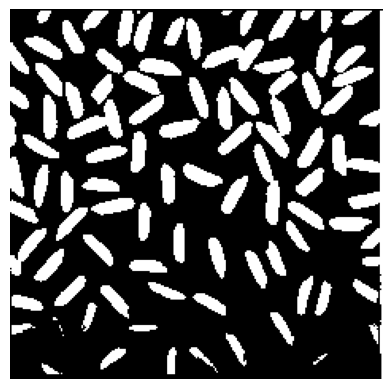

In [15]:
from scipy.ndimage import binary_erosion
_,binary=cv2.threshold(fig2,127,1,cv2.THRESH_BINARY)
show_image(binary)

# Q 3.Determine the number of objects in the binary image generated in Question 2 using the concept of connectivity.

In [16]:
num_labels, labels = cv2.connectedComponents(binary)

print(f"Number of objects: {num_labels -1}")

Number of objects: 89


# Q 4. Find the Euclidean Distance between two points of the image.

In [17]:
pt1 = (10, 10)
pt2 = (50, 50)
dist = distance.euclidean(pt1, pt2)
print("Euclidean Distance between two points of the image:",dist)

Euclidean Distance between two points of the image: 56.568542494923804


# Q 5.	Apply the following operations using Fig.1 and Fig.2:


1.   Addition
2.   Substraction


1.   Multiplication

1.   Division

# 5.1 Addition

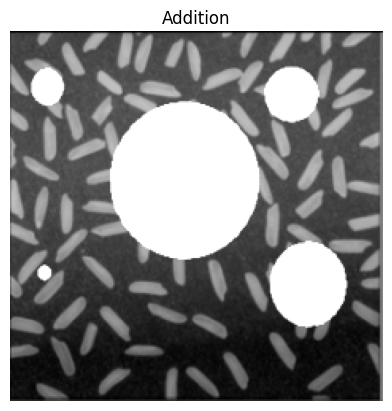

In [18]:
addition = cv2.add(fig1, fig2)
plt.imshow(addition, cmap='gray')
plt.title("Addition")
plt.axis("off")
plt.show()

# 5.2  Substraction

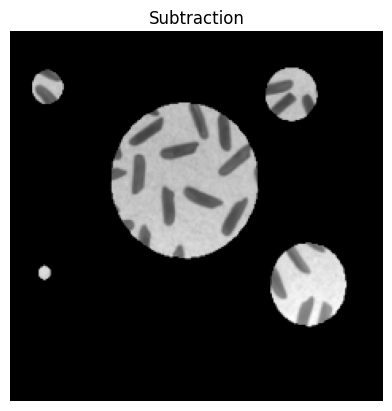

In [19]:
subtraction = cv2.subtract(fig1, fig2)
plt.imshow(subtraction, cmap='gray')
plt.title("Subtraction")
plt.axis("off")
plt.show()

# 5.3   Multiplication

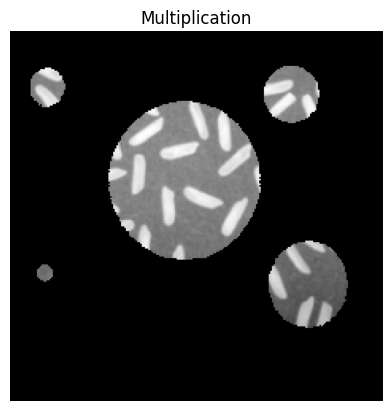

In [20]:
multiplication = cv2.bitwise_and(fig2, fig2, mask=fig1)
plt.imshow(multiplication, cmap='gray')
plt.title("Multiplication")
plt.axis("off")
plt.show()

# 5.4   Division

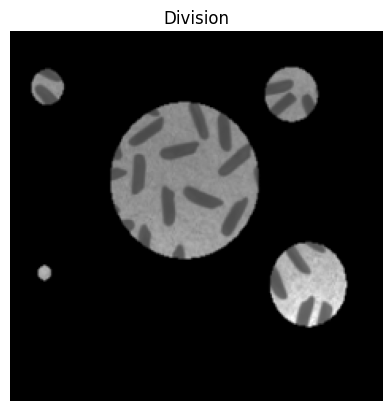

In [21]:
fig1_float = fig1.astype(np.float32)
fig2_float = fig2.astype(np.float32) + 1
division = cv2.divide(fig1_float, fig2_float)
plt.imshow(division, cmap='gray')
plt.title("Division")
plt.axis("off")
plt.show()

# Q 6.	Apply the following operations using Fig.1 and Fig.2:


1.   AND
2.   OR


1.   NOT

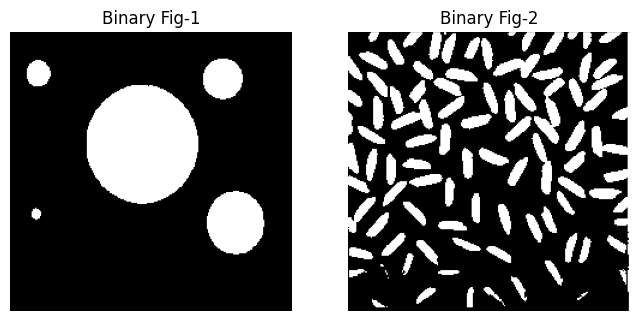

In [22]:
# Converting Images to Binary

_, fig1_bin = cv2.threshold(fig1, 127, 255, cv2.THRESH_BINARY)
_, fig2_bin = cv2.threshold(fig2, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(fig1_bin, cmap='gray')
plt.title("Binary Fig-1")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(fig2_bin, cmap='gray')
plt.title("Binary Fig-2")
plt.axis("off")
plt.show()

# 6.1 AND

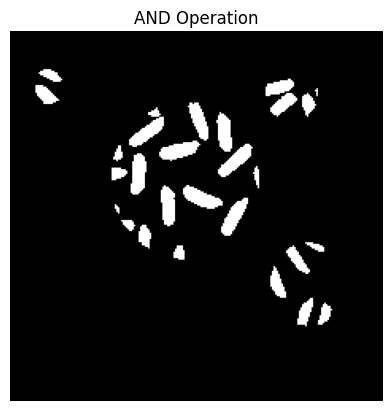

In [23]:
and_result = cv2.bitwise_and(fig1_bin, fig2_bin)
plt.imshow(and_result, cmap='gray')
plt.title("AND Operation")
plt.axis("off")
plt.show()

# 6.2  OR

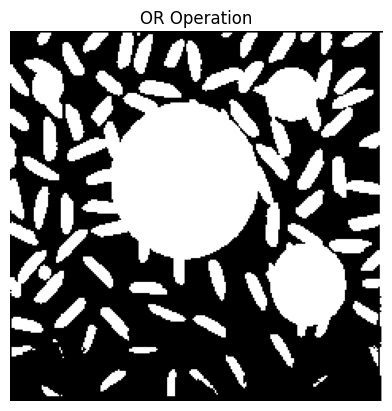

In [24]:
or_result = cv2.bitwise_or(fig1_bin, fig2_bin)
plt.imshow(or_result, cmap='gray')
plt.title("OR Operation")
plt.axis("off")
plt.show()

# 6.3 NOT

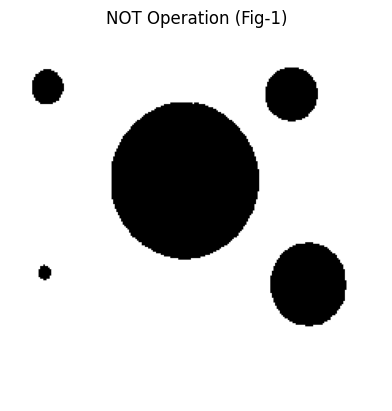

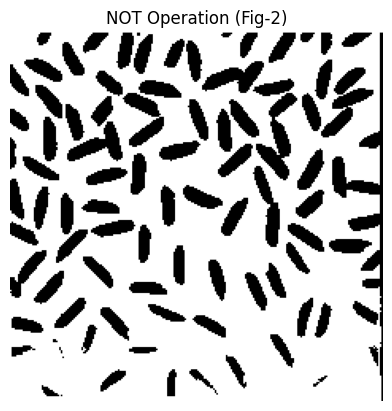

In [25]:
not_result = cv2.bitwise_not(fig1_bin)
plt.imshow(not_result, cmap='gray')
plt.title("NOT Operation (Fig-1)")
plt.axis("off")
plt.show()
not_result = cv2.bitwise_not(fig2_bin)
plt.imshow(not_result, cmap='gray')
plt.title("NOT Operation (Fig-2)")
plt.axis("off")
plt.show()